##  Step 1 — Import All Required Libraries


In [25]:
import pandas as pd          
import numpy as np          
import matplotlib.pyplot as plt   
import seaborn as sns             

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA        

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.metrics import silhouette_score 

import warnings
warnings.filterwarnings('ignore')  

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully!")


All libraries imported successfully!


## Step 2 — Load the Dataset


In [26]:
# Load the main dataset
df = pd.read_csv('Country-data.csv')

# Load the data dictionary (column descriptions)
dictionary = pd.read_csv('data-dictionary.csv')

print("Data loaded!")
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("First 5 rows of the dataset:")
df.head()


Data loaded!
Dataset shape: 167 rows × 10 columns
First 5 rows of the dataset:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [27]:
# Basic information
print("Dataset Info:")
print(f"  • Total Countries : {df.shape[0]}")
print(f"  • Total Features  : {df.shape[1]}")
print()
print("Column Data Types:")
print(df.dtypes)


Dataset Info:
  • Total Countries : 167
  • Total Features  : 10

Column Data Types:
country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object


##  Step 3 — Exploratory Data Analysis (EDA)


In [28]:
# Statistical Summary
print("Statistical Summary of All Columns:")
df.describe().round(2)


Statistical Summary of All Columns:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


In [29]:
# Check for missing values
print("Missing Values in Each Column:")
missing = df.isnull().sum()
print(missing)
print()
if missing.sum() == 0:
    print("No missing values found.")
else:
    print(f" Total missing values: {missing.sum()}")


Missing Values in Each Column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

No missing values found.


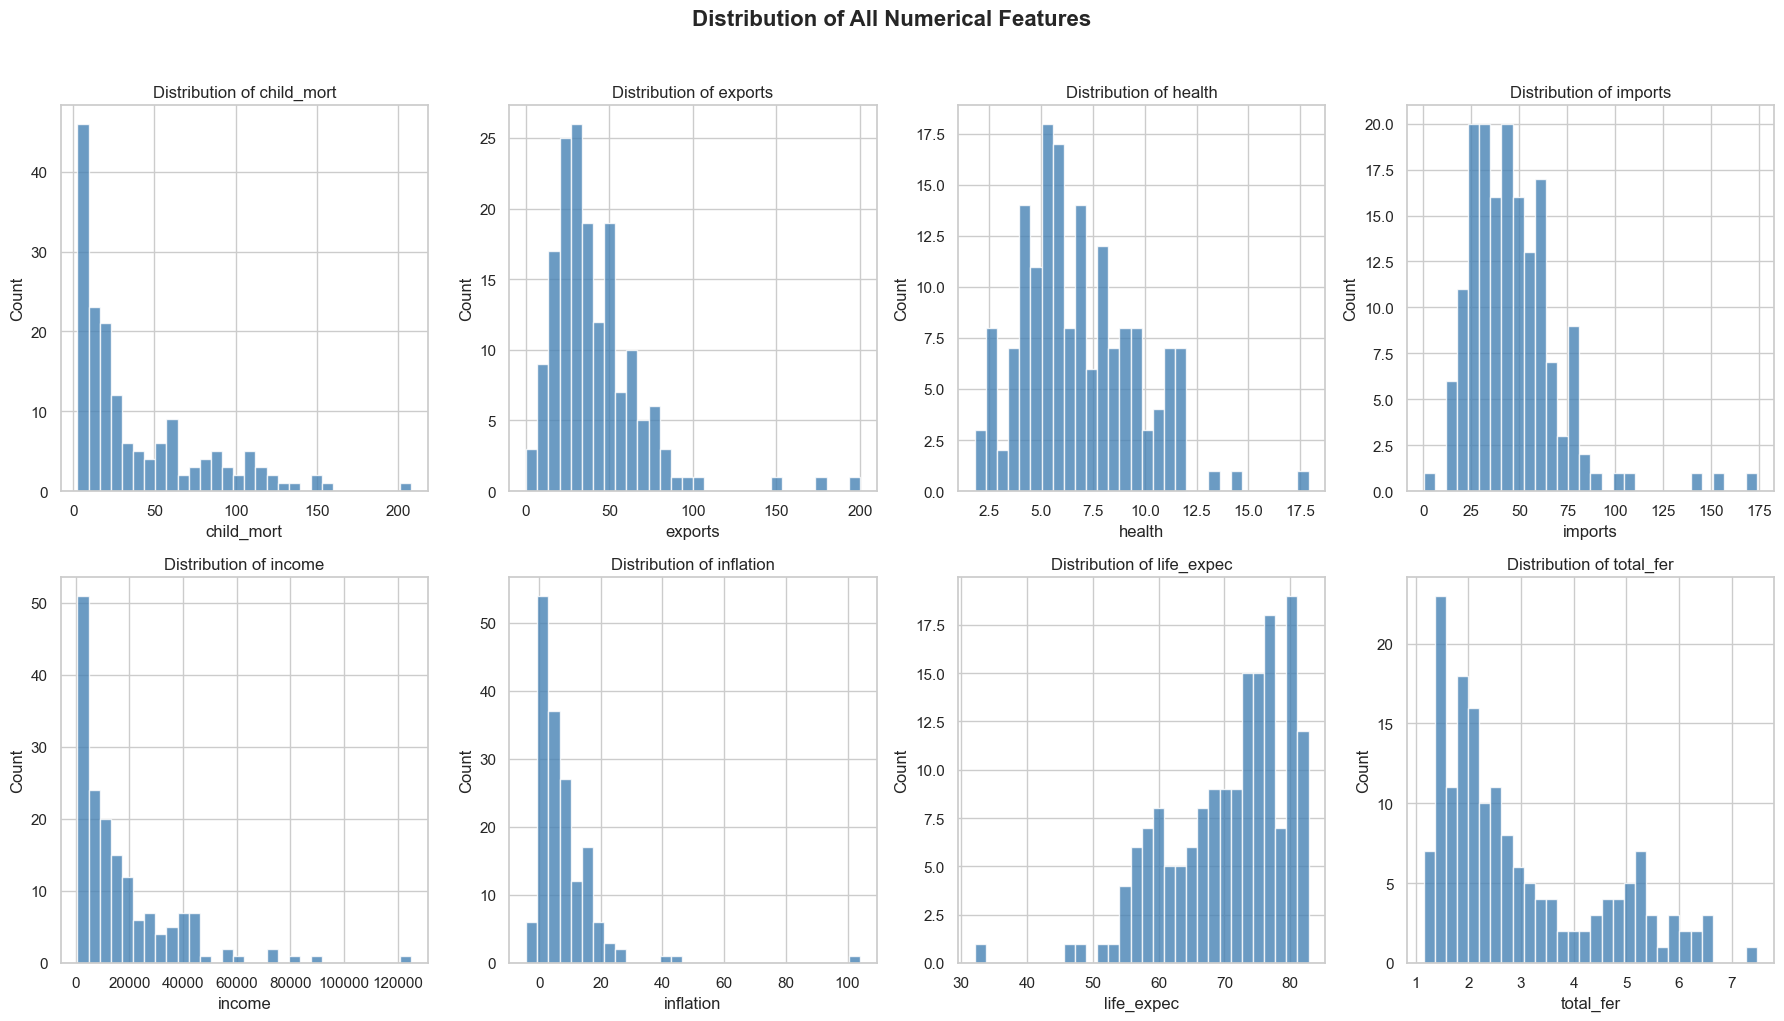

Each chart shows how often different values appear for that feature.


In [30]:
# Plot 1: Distribution of Key Features
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

features = ['child_mort', 'exports', 'health', 'imports',
            'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
numeric_features = [c for c in features if c in df.columns][:8]

for i, col in enumerate(numeric_features):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of All Numerical Features', fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()
print("Each chart shows how often different values appear for that feature.")


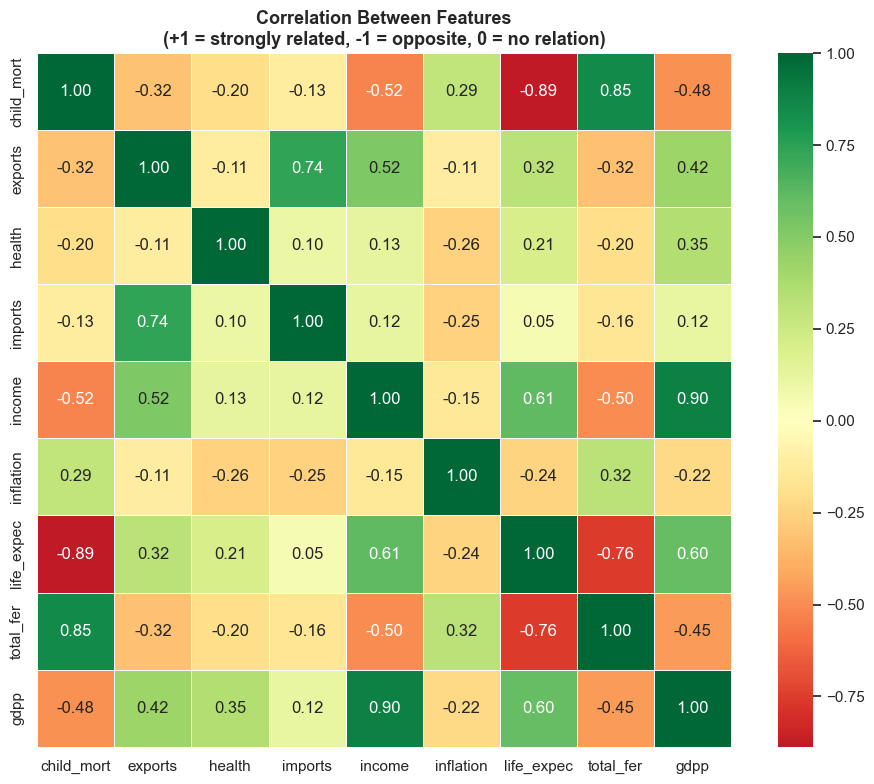


Key Insights from Heatmap:
  • child_mort & life_expec are strongly NEGATIVELY correlated
  • gdpp & income are strongly POSITIVELY correlated
  • These patterns make real-world sense!


In [31]:
# Plot 2: Correlation Heatmap
numeric_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    square=True, linewidths=0.5
)
plt.title('Correlation Between Features\n(+1 = strongly related, -1 = opposite, 0 = no relation)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Insights from Heatmap:")
print("  • child_mort & life_expec are strongly NEGATIVELY correlated")
print("  • gdpp & income are strongly POSITIVELY correlated")
print("  • These patterns make real-world sense!")


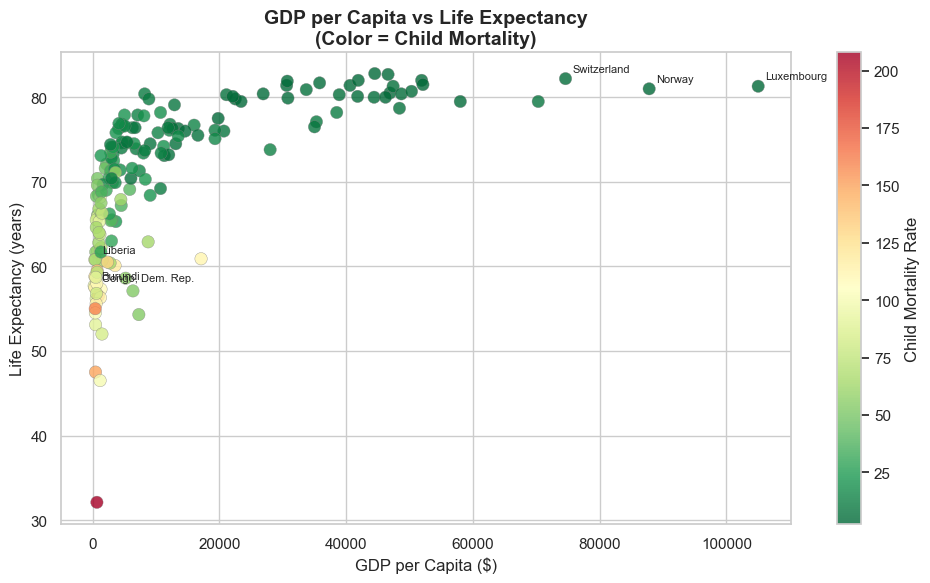

Richer countries (high GDP) tend to have longer life expectancy and lower child mortality.


In [32]:
# Plot 3: GDP vs Life Expectancy Scatter
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['gdpp'], df['life_expec'],
    c=df['child_mort'], cmap='RdYlGn_r',
    s=80, alpha=0.8, edgecolors='gray', linewidth=0.3
)
plt.colorbar(scatter, label='Child Mortality Rate')
plt.xlabel('GDP per Capita ($)', fontsize=12)
plt.ylabel('Life Expectancy (years)', fontsize=12)
plt.title('GDP per Capita vs Life Expectancy\n(Color = Child Mortality)', fontsize=14, fontweight='bold')

# Annotate a few interesting countries
for _, row in df.nlargest(3, 'gdpp').iterrows():
    plt.annotate(row['country'], (row['gdpp'], row['life_expec']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)
for _, row in df.nsmallest(3, 'gdpp').iterrows():
    plt.annotate(row['country'], (row['gdpp'], row['life_expec']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)

plt.tight_layout()
plt.show()
print("Richer countries (high GDP) tend to have longer life expectancy and lower child mortality.")


## Step 4 — Feature Engineering & Label Creation

Since our dataset has NO pre-existing labels (it's unsupervised data), we will **create labels** based on domain knowledge.

We'll classify each country into one of **3 categories**:
- **Developed** — High income, high life expectancy, low child mortality
- **Developing** — Mid values
- **Underdeveloped** — Low income, low life expectancy, high child mortality


In [33]:
# Create a Development Score
# We normalize each relevant column and combine them into a single score

from sklearn.preprocessing import MinMaxScaler
scaler_label = MinMaxScaler()

# Positive indicators (higher = better)
positive = ['income', 'life_expec', 'health']
# Negative indicators (lower = better)
negative = ['child_mort', 'total_fer', 'inflation']

df_score = df.copy()

# Scale positive features between 0 and 1
for col in positive:
    df_score[col + '_norm'] = scaler_label.fit_transform(df[[col]])

# Scale negative features and INVERT (1 - value so lower = worse)
for col in negative:
    df_score[col + '_norm'] = 1 - scaler_label.fit_transform(df[[col]])

# Compute development score (average of all normalized features)
norm_cols = [c + '_norm' for c in positive + negative]
df_score['dev_score'] = df_score[norm_cols].mean(axis=1)

print("Development Score Summary:")
print(df_score['dev_score'].describe().round(3))
print()

# Assign labels based on score thresholds
def assign_label(score):
    if score >= 0.60:
        return 'Developed'
    elif score >= 0.35:
        return 'Developing'
    else:
        return 'Underdeveloped'

df_score['label'] = df_score['dev_score'].apply(assign_label)
df['label'] = df_score['label']

print("Label Distribution:")
print(df['label'].value_counts())
print()
print("Sample Labelled Countries:")
print(df[['country', 'gdpp', 'life_expec', 'child_mort', 'label']].sample(10, random_state=42).to_string(index=False))


Development Score Summary:
count    167.000
mean       0.606
std        0.128
min        0.240
25%        0.524
50%        0.627
75%        0.700
max        0.853
Name: dev_score, dtype: float64

Label Distribution:
label
Developed         93
Developing        68
Underdeveloped     6
Name: count, dtype: int64

Sample Labelled Countries:
              country  gdpp  life_expec  child_mort      label
Micronesia, Fed. Sts.  2860        65.4        40.0  Developed
              Namibia  5190        58.6        56.0 Developing
               Jordan  3680        75.8        21.1  Developed
               Gambia   562        65.5        80.3 Developing
                Malta 21100        80.3         6.8  Developed
               Canada 47400        81.3         5.6  Developed
              Morocco  2830        73.5        33.5  Developed
               Kuwait 38500        78.2        10.8  Developed
           Montenegro  6680        76.4         6.8  Developed
                Nepal   592    

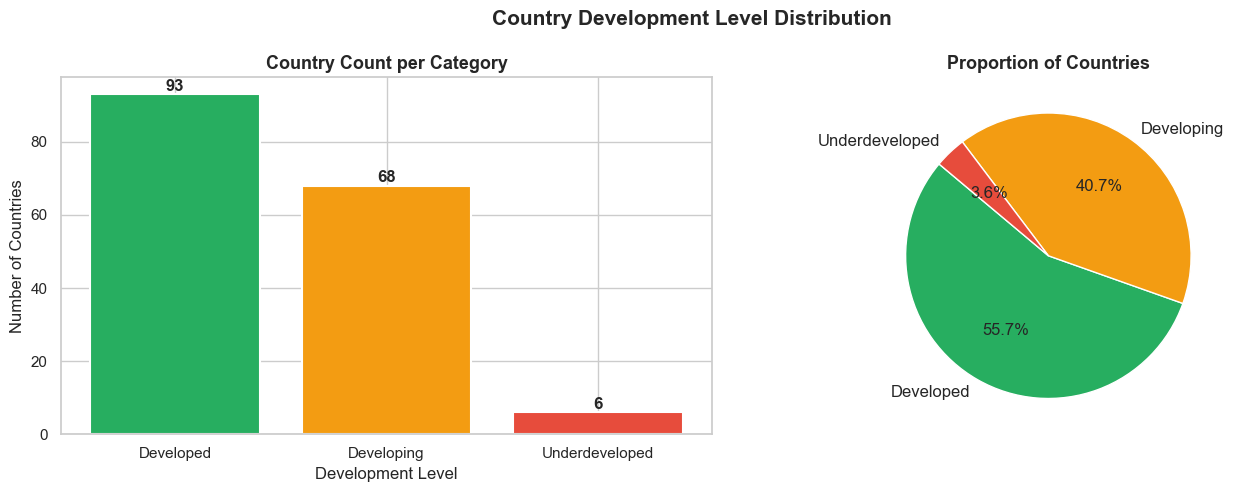

In [12]:
# ── Plot 4: Label Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df['label'].value_counts()
colors = {'Developed': '#27ae60', 'Developing': '#f39c12', 'Underdeveloped': '#e74c3c'}
bar_colors = [colors[l] for l in counts.index]
axes[0].bar(counts.index, counts.values, color=bar_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Country Count per Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Development Level')
axes[0].set_ylabel('Number of Countries')
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 1, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=bar_colors,
            autopct='%1.1f%%', startangle=140,
            textprops={'fontsize': 12})
axes[1].set_title('Proportion of Countries', fontsize=13, fontweight='bold')

plt.suptitle('Country Development Level Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 5 — Data Preprocessing


In [34]:
# Select Features & Target
feature_cols = ['child_mort', 'exports', 'health', 'imports',
                'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

X = df[feature_cols]   # Features (inputs to the model)
y = df['label']        # Target (what we want to predict)

# Encode Labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label Encoding Map:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

# Scale Features
# StandardScaler makes all features have mean=0 and std=1
# This prevents big numbers (like gdpp) from dominating small ones
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print()
print("Features scaled (mean ~0, std ~1):")
print(X_scaled.describe().round(2))


Label Encoding Map:
  Developed → 0
  Developing → 1
  Underdeveloped → 2

Features scaled (mean ~0, std ~1):
       child_mort  exports  health  imports  income  inflation  life_expec  \
count      167.00   167.00  167.00   167.00  167.00     167.00      167.00   
mean        -0.00     0.00    0.00     0.00   -0.00      -0.00        0.00   
std          1.00     1.00    1.00     1.00    1.00       1.00        1.00   
min         -0.89    -1.50   -1.83    -1.94   -0.86      -1.14       -4.34   
25%         -0.75    -0.63   -0.69    -0.69   -0.72      -0.57       -0.59   
50%         -0.47    -0.22   -0.18    -0.15   -0.37      -0.23        0.29   
75%          0.59     0.37    0.65     0.49    0.29       0.28        0.70   
max          4.22     5.81    4.05     5.27    5.61       9.13        1.38   

       total_fer    gdpp  
count     167.00  167.00  
mean        0.00    0.00  
std         1.00    1.00  
min        -1.19   -0.70  
25%        -0.76   -0.64  
50%        -0.36   -0.45 

In [35]:
# Train-Test Split
# 80% of data for training, 20% for testing
# random_state=42 ensures reproducibility (same split every time)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # Ensure equal class ratio in train & test
)

print("Data Split Complete:")
print(f"  Training set   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X_scaled)*100:.0f}%)")
print(f"  Testing set    : {X_test.shape[0]} samples  ({X_test.shape[0]/len(X_scaled)*100:.0f}%)")
print()
print("Class distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]}: {c} samples")


Data Split Complete:
  Training set   : 133 samples (80%)
  Testing set    : 34 samples  (20%)

Class distribution in training set:
  Developed: 74 samples
  Developing: 54 samples
  Underdeveloped: 5 samples


## Step 6 — Random Forest Classifier




In [36]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,     # Number of trees
    max_depth=10,         # Maximum depth of each tree
    random_state=42,      # For reproducibility
    n_jobs=-1             # Use all CPU cores
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluate
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Results:")
print(f"   Test Accuracy: {rf_acc * 100:.2f}%")
print()

# Cross-validation score 
cv_scores_rf = cross_val_score(rf_model, X_scaled, y_encoded, cv=5, scoring='accuracy')
print(f"   5-Fold Cross-Validation Accuracy: {cv_scores_rf.mean()*100:.2f}% ± {cv_scores_rf.std()*100:.2f}%")
print()
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))


Random Forest Results:
   Test Accuracy: 94.12%

   5-Fold Cross-Validation Accuracy: 91.00% ± 3.35%

Detailed Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      0.95      0.97        19
    Developing       0.88      1.00      0.93        14
Underdeveloped       0.00      0.00      0.00         1

      accuracy                           0.94        34
     macro avg       0.62      0.65      0.64        34
  weighted avg       0.92      0.94      0.93        34



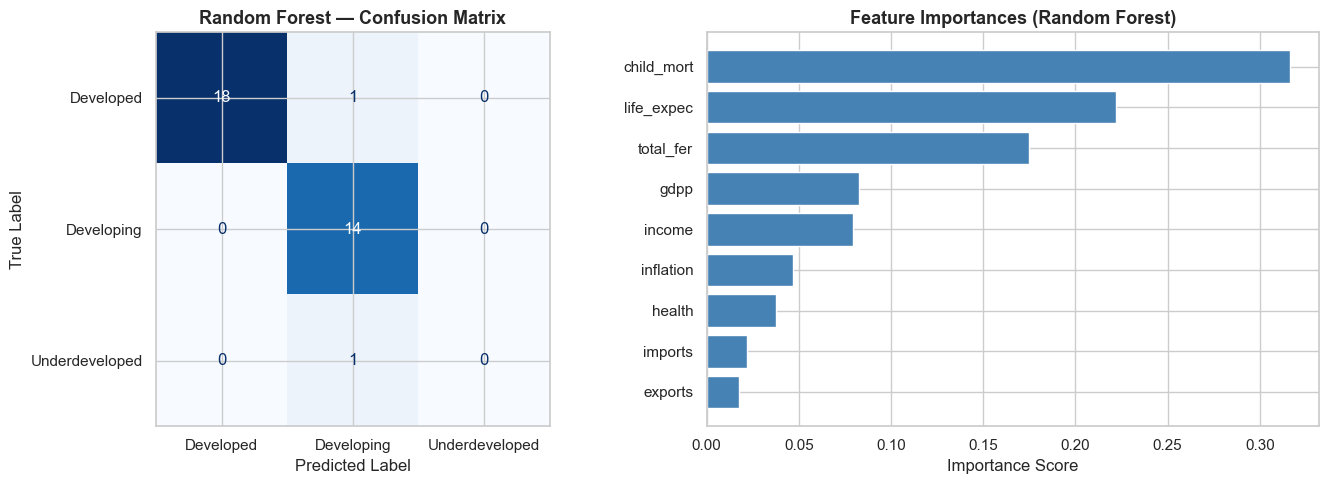

The confusion matrix shows: rows = actual class, columns = predicted class.
   Diagonal cells = correct predictions. Off-diagonal = mistakes.


In [37]:
# Confusion Matrix for Random Forest 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le.classes_)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
axes[1].barh(
    [feature_cols[i] for i in indices],
    importances[indices],
    color='steelblue', edgecolor='white'
)
axes[1].set_title('Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
print("The confusion matrix shows: rows = actual class, columns = predicted class.")
print("   Diagonal cells = correct predictions. Off-diagonal = mistakes.")


## Step 7 — XGBoost Classifier

In [38]:
# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,      # Number of boosting rounds
    max_depth=4,           # Depth of each tree
    learning_rate=0.1,     # How fast it learns (smaller = more careful)
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate 
xgb_acc = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Results:")
print(f"   Test Accuracy: {xgb_acc * 100:.2f}%")
print()

cv_scores_xgb = cross_val_score(xgb_model, X_scaled, y_encoded, cv=5, scoring='accuracy')
print(f"   5-Fold Cross-Validation Accuracy: {cv_scores_xgb.mean()*100:.2f}% ± {cv_scores_xgb.std()*100:.2f}%")
print()
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))


XGBoost Results:
   Test Accuracy: 91.18%

   5-Fold Cross-Validation Accuracy: 86.86% ± 5.46%

Detailed Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      0.89      0.94        19
    Developing       0.82      1.00      0.90        14
Underdeveloped       0.00      0.00      0.00         1

      accuracy                           0.91        34
     macro avg       0.61      0.63      0.62        34
  weighted avg       0.90      0.91      0.90        34



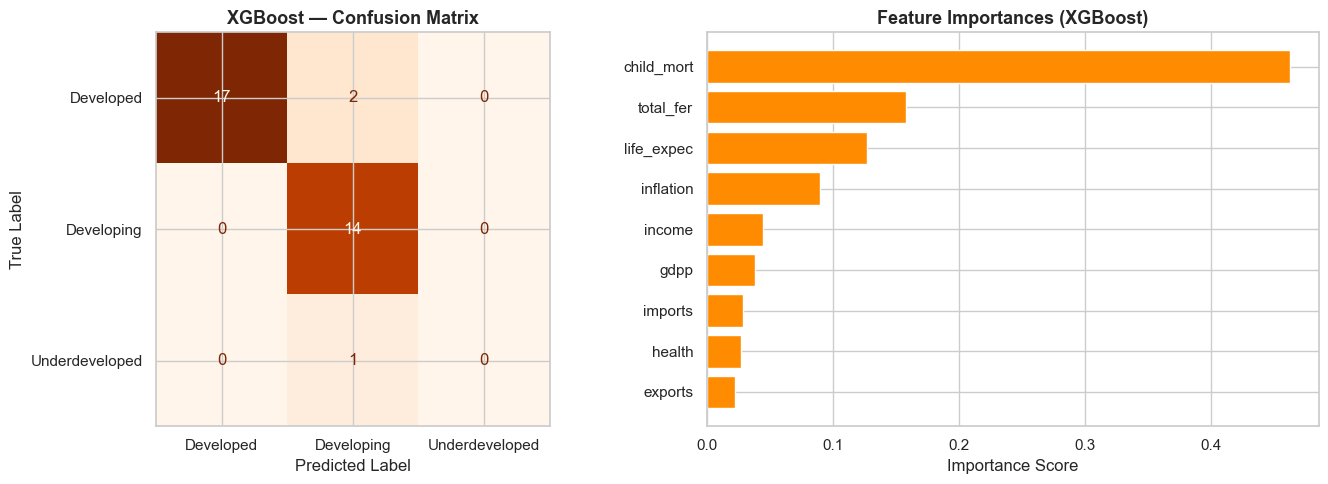

In [39]:
# Confusion Matrix for XGBoost 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=le.classes_)
disp.plot(ax=axes[0], cmap='Oranges', colorbar=False)
axes[0].set_title('XGBoost — Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Feature Importance for XGBoost
xgb_importances = xgb_model.feature_importances_
indices_xgb = np.argsort(xgb_importances)[::-1]
axes[1].barh(
    [feature_cols[i] for i in indices_xgb],
    xgb_importances[indices_xgb],
    color='darkorange', edgecolor='white'
)
axes[1].set_title('Feature Importances (XGBoost)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


##  Step 8 — Model Comparison

Let's compare Random Forest vs XGBoost side by side.

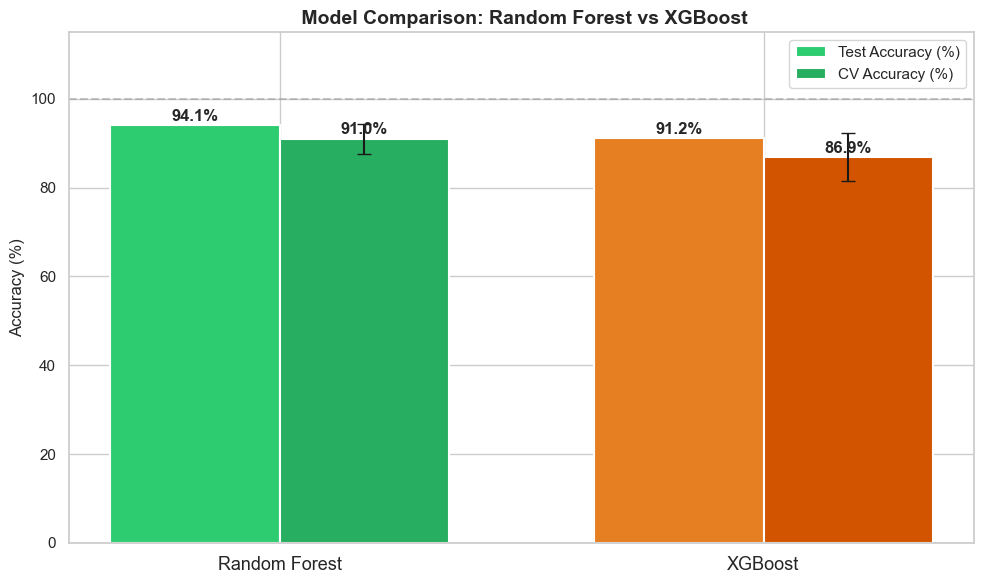


Summary Table:
Model                  Test Acc       CV Acc
--------------------------------------------
Random Forest            94.12%  91.00% ± 3.35%
XGBoost                  91.18%  86.86% ± 5.46%


In [40]:
# Side-by-side Model Comparison 
models = ['Random Forest', 'XGBoost']
test_accs = [rf_acc * 100, xgb_acc * 100]
cv_means = [cv_scores_rf.mean() * 100, cv_scores_xgb.mean() * 100]
cv_stds  = [cv_scores_rf.std() * 100,  cv_scores_xgb.std() * 100]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, test_accs, width, label='Test Accuracy (%)',
               color=['#2ecc71', '#e67e22'], edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, cv_means, width, label='CV Accuracy (%)',
               color=['#27ae60', '#d35400'], edgecolor='white', linewidth=1.5,
               yerr=cv_stds, capsize=5)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=13)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title(' Model Comparison: Random Forest vs XGBoost', fontsize=14, fontweight='bold')
ax.set_ylim(0, 115)
ax.legend(fontsize=11)
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.4)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSummary Table:")
print(f"{'Model':<20} {'Test Acc':>10} {'CV Acc':>12}")
print("-" * 44)
for m, ta, cv, std in zip(models, test_accs, cv_means, cv_stds):
    print(f"{m:<20} {ta:>9.2f}%  {cv:.2f}% ± {std:.2f}%")


## Step 9 — Ensemble Model (Voting Classifier)

**What is an Ensemble?**
- We combine multiple models so they vote together
- If both models agree → high confidence
- If they disagree → the majority wins
- Usually gives better results than any single model!


In [41]:
# Voting Classifier (combine RF + XGBoost)
ensemble_model = VotingClassifier(
    estimators=[
        ('random_forest', rf_model),
        ('xgboost', xgb_model)
    ],
    voting='soft'   # 'soft' uses predicted probabilities (better than 'hard')
)

ensemble_model.fit(X_train, y_train)
y_pred_ensemble = ensemble_model.predict(X_test)

ensemble_acc = accuracy_score(y_test, y_pred_ensemble)
cv_scores_ensemble = cross_val_score(ensemble_model, X_scaled, y_encoded, cv=5)

print(f" Ensemble Model Results:")
print(f"   Test Accuracy: {ensemble_acc * 100:.2f}%")
print(f"   5-Fold CV Accuracy: {cv_scores_ensemble.mean()*100:.2f}% ± {cv_scores_ensemble.std()*100:.2f}%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_ensemble, target_names=le.classes_))


 Ensemble Model Results:
   Test Accuracy: 91.18%
   5-Fold CV Accuracy: 88.02% ± 5.40%

Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      0.89      0.94        19
    Developing       0.82      1.00      0.90        14
Underdeveloped       0.00      0.00      0.00         1

      accuracy                           0.91        34
     macro avg       0.61      0.63      0.62        34
  weighted avg       0.90      0.91      0.90        34



##  Step 10 — K-Means Clustering

**What is K-Means?**
- Clustering = grouping similar things together WITHOUT labels
- K-Means finds K groups (clusters) by minimizing distance between points and their cluster center
- We use the **Elbow Method** to find the best K


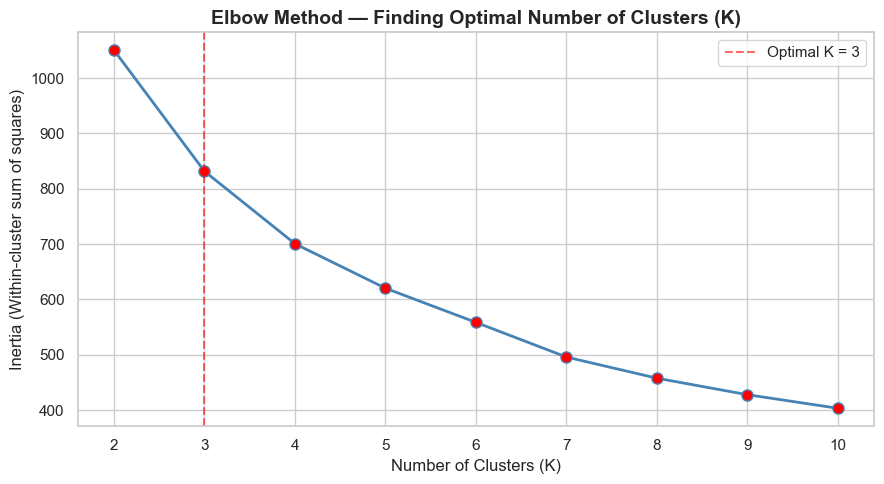

The 'elbow' point is where adding more clusters gives less improvement.
   K=3 is a good choice here (matches our 3 development categories).


In [42]:
# Elbow Method to find best K 
inertia_values = []  # Inertia = sum of distances to nearest cluster center
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(K_range, inertia_values, marker='o', color='steelblue',
         linewidth=2, markersize=8, markerfacecolor='red')
plt.title('Elbow Method — Finding Optimal Number of Clusters (K)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
plt.xticks(K_range)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.6, label='Optimal K = 3')
plt.legend()
plt.tight_layout()
plt.show()

print("The 'elbow' point is where adding more clusters gives less improvement.")
print("   K=3 is a good choice here (matches our 3 development categories).")


In [43]:
#Train K-Means with K=3
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans_model.fit_predict(X_scaled)

# Silhouette Score (higher = better separated clusters, max = 1.0)
sil_score_km = silhouette_score(X_scaled, df['kmeans_cluster'])
print(f"K-Means Clustering Done!")
print(f"   Silhouette Score: {sil_score_km:.4f}  (closer to 1.0 = better)")
print()
print("Countries per Cluster:")
print(df['kmeans_cluster'].value_counts().sort_index())


K-Means Clustering Done!
   Silhouette Score: 0.2833  (closer to 1.0 = better)

Countries per Cluster:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


PCA Explained Variance: PC1=46.0%, PC2=17.2%, Total=63.1%


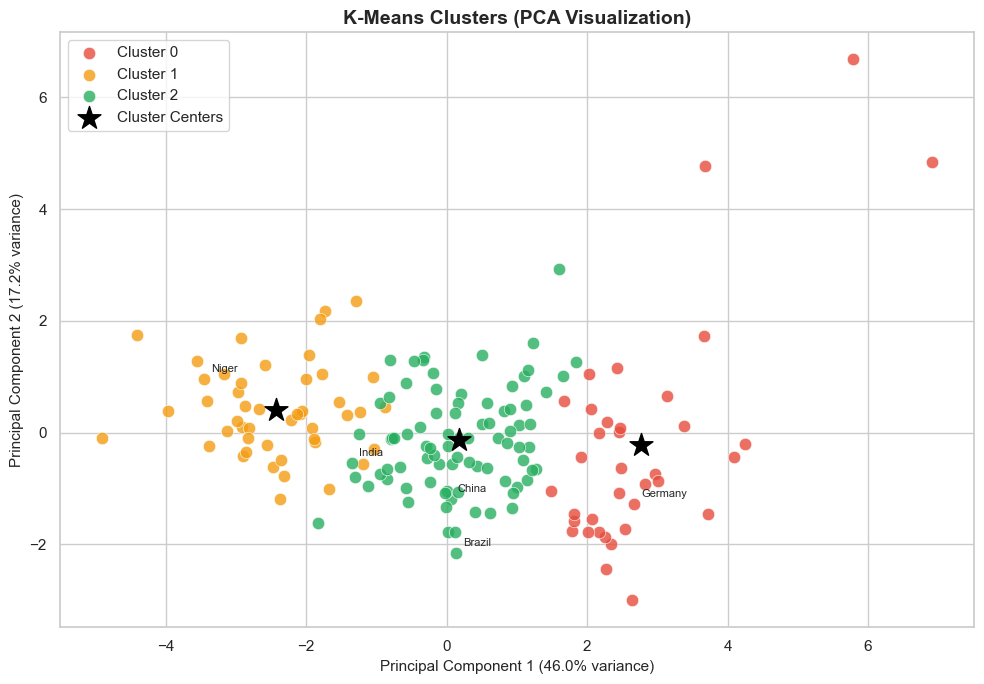

In [44]:
# Visualize K-Means Clusters using PCA
# PCA reduces 9 features → 2 dimensions so we can plot them
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_ * 100
print(f"PCA Explained Variance: PC1={explained[0]:.1f}%, PC2={explained[1]:.1f}%, Total={sum(explained):.1f}%")

plt.figure(figsize=(10, 7))
colors_cluster = ['#e74c3c', '#f39c12', '#27ae60']
cluster_names  = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for i in range(3):
    mask = df['kmeans_cluster'] == i
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=cluster_names[i], color=colors_cluster[i],
        s=80, alpha=0.8, edgecolors='white', linewidth=0.5
    )

# Plot cluster centers
centers_pca = pca.transform(kmeans_model.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            s=300, marker='*', c='black', label='Cluster Centers', zorder=5)

# Annotate some countries
for i in range(len(df)):
    if df.iloc[i]['country'] in ['United States of America', 'India', 'Niger', 'Germany', 'Brazil', 'China']:
        plt.annotate(df.iloc[i]['country'],
                     (X_pca[i, 0], X_pca[i, 1]),
                     textcoords='offset points', xytext=(5, 5), fontsize=8)

plt.xlabel(f'Principal Component 1 ({explained[0]:.1f}% variance)', fontsize=11)
plt.ylabel(f'Principal Component 2 ({explained[1]:.1f}% variance)', fontsize=11)
plt.title('K-Means Clusters (PCA Visualization)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


##  Step 11 — DBSCAN Clustering

**What is DBSCAN?**
- DBSCAN = Density-Based Spatial Clustering of Applications with Noise
- Unlike K-Means, you DON'T need to specify the number of clusters
- It finds clusters based on density (how close points are to each other)
- It can detect **outliers/noise** (marked as -1)
- Great for finding unusual/anomalous countries!


In [45]:
# Train DBSCAN
dbscan_model = DBSCAN(
    eps=1.5,          # Maximum distance between two samples to be neighbors
    min_samples=5     # Minimum points to form a dense region (cluster)
)

df['dbscan_cluster'] = dbscan_model.fit_predict(X_scaled)

n_clusters_db = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise       = (df['dbscan_cluster'] == -1).sum()

print(f" DBSCAN Clustering Done!")
print(f"   Number of clusters found : {n_clusters_db}")
print(f"   Noise points (outliers)  : {n_noise}")
print()
print(" Cluster Distribution:")
cluster_counts = df['dbscan_cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    label = 'NOISE/Outlier' if cluster == -1 else f'Cluster {cluster}'
    print(f"  {label}: {count} countries")


 DBSCAN Clustering Done!
   Number of clusters found : 1
   Noise points (outliers)  : 30

 Cluster Distribution:
  NOISE/Outlier: 30 countries
  Cluster 0: 137 countries


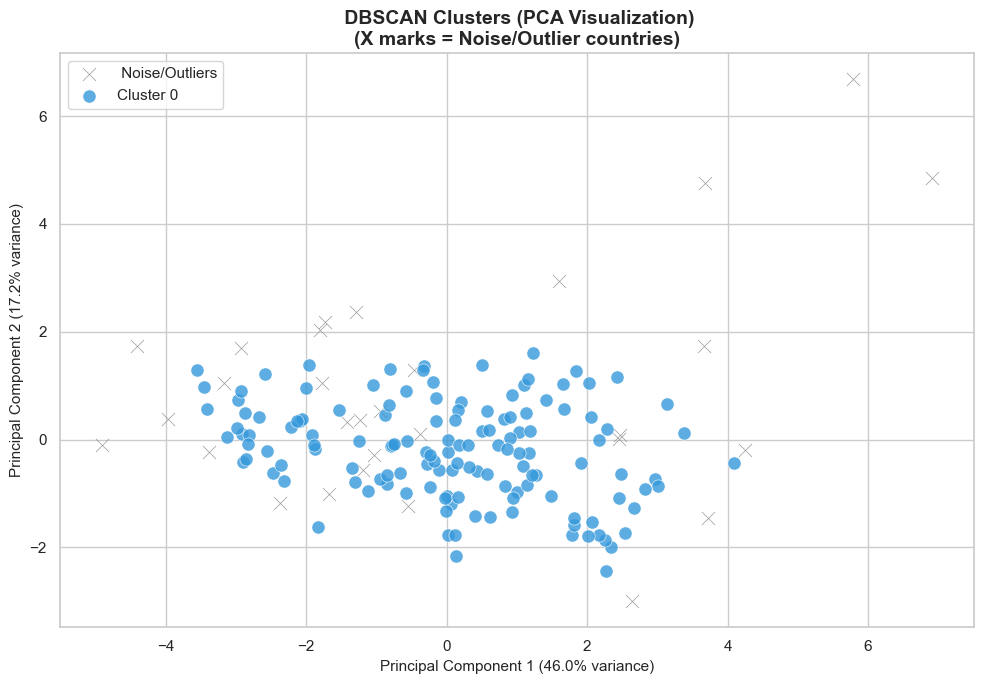


 Outlier Countries Detected by DBSCAN:
                 country   gdpp  child_mort  life_expec
                  Angola   3530       119.0        60.1
                  Brunei  35300        10.5        77.1
Central African Republic    446       149.0        47.5
        Congo, Dem. Rep.    334       116.0        57.5
             Congo, Rep.   2740        63.9        60.4
       Equatorial Guinea  17100       111.0        60.9
                   Gabon   8750        63.7        62.9
                   Haiti    662       208.0        32.1
                    Iraq   4500        36.9        67.2
                 Ireland  48700         4.2        80.4
                Kiribati   1490        62.7        60.7
                  Kuwait  38500        10.8        78.2
                 Lesotho   1170        99.7        46.5
                 Liberia    327        89.3        60.8
              Luxembourg 105000         2.8        81.3
                   Malta  21100         6.8        80.3
   Micro

In [46]:
# Visualize DBSCAN Clusters
plt.figure(figsize=(10, 7))

unique_clusters = sorted(df['dbscan_cluster'].unique())
palette = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']

for i, cluster in enumerate(unique_clusters):
    mask = df['dbscan_cluster'] == cluster
    label = ' Noise/Outliers' if cluster == -1 else f'Cluster {cluster}'
    color = 'gray' if cluster == -1 else palette[i % len(palette)]
    marker = 'x' if cluster == -1 else 'o'
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=label, color=color, s=90,
        alpha=0.8, marker=marker,
        edgecolors='white' if cluster != -1 else None,
        linewidth=0.5
    )

plt.xlabel(f'Principal Component 1 ({explained[0]:.1f}% variance)', fontsize=11)
plt.ylabel(f'Principal Component 2 ({explained[1]:.1f}% variance)', fontsize=11)
plt.title(' DBSCAN Clusters (PCA Visualization)\n(X marks = Noise/Outlier countries)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Show outlier countries
outliers = df[df['dbscan_cluster'] == -1][['country', 'gdpp', 'child_mort', 'life_expec']]
print(f"\n Outlier Countries Detected by DBSCAN:")
print(outliers.to_string(index=False))
print("These countries have unusual combinations of features.")


## Step 12 — Cluster Profiling & Actionable Insights


In [47]:
#  K-Means Cluster Profiles 
cluster_profile = df.groupby('kmeans_cluster')[feature_cols].mean().round(2)
print("K-Means Cluster Profiles (Average Feature Values):")
print(cluster_profile.to_string())
print()

# Map cluster numbers to meaningful names
# Based on gdpp and life_expectancy
cluster_gdpp = cluster_profile['gdpp']
cluster_map = {}
sorted_clusters = cluster_gdpp.sort_values(ascending=False).index.tolist()
cluster_labels = ['Developed', 'Developing', 'Underdeveloped']
for cluster_id, label in zip(sorted_clusters, cluster_labels):
    cluster_map[cluster_id] = label

df['cluster_label'] = df['kmeans_cluster'].map(cluster_map)
print("Cluster → Development Level Mapping:")
for k, v in cluster_map.items():
    print(f"   Cluster {k} → {v}")


K-Means Cluster Profiles (Average Feature Values):
                child_mort  exports  health  imports    income  inflation  life_expec  total_fer      gdpp
kmeans_cluster                                                                                            
0                     5.00    58.74    8.81    51.49  45672.22       2.67       80.13       1.75  42494.44
1                    92.96    29.15    6.39    42.32   3942.40      12.02       59.19       5.01   1922.38
2                    21.93    40.24    6.20    47.47  12305.60       7.60       72.81       2.31   6486.45

Cluster → Development Level Mapping:
   Cluster 0 → Developed
   Cluster 2 → Developing
   Cluster 1 → Underdeveloped


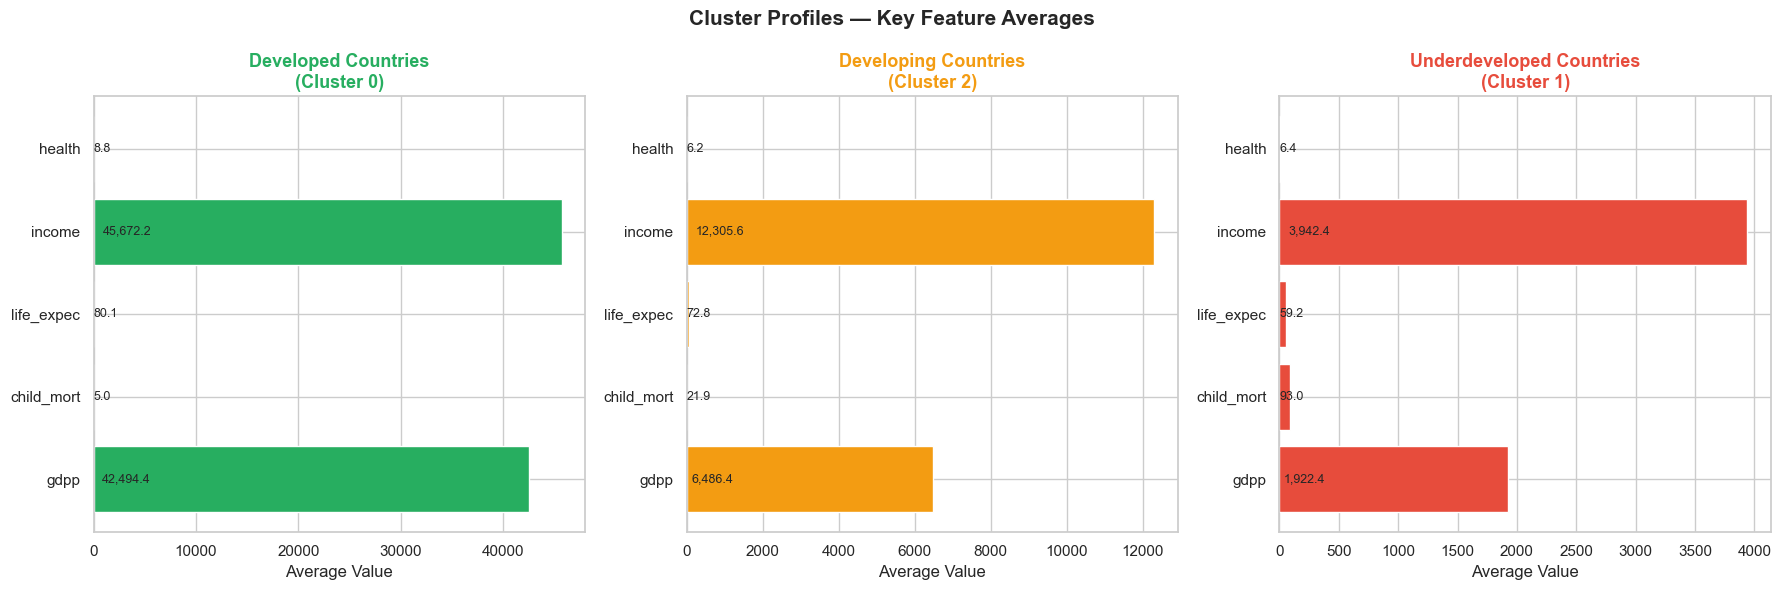

In [48]:
# Plot Cluster Profiles (Radar / Bar) 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

key_features = ['gdpp', 'child_mort', 'life_expec', 'income', 'health']
cluster_colors = {'Developed': '#27ae60', 'Developing': '#f39c12', 'Underdeveloped': '#e74c3c'}

for ax, (cluster_id, label) in zip(axes, [(sorted_clusters[0], 'Developed'),
                                            (sorted_clusters[1], 'Developing'),
                                            (sorted_clusters[2], 'Underdeveloped')]):
    vals = cluster_profile.loc[cluster_id, key_features].values
    ax.barh(key_features, vals, color=cluster_colors[label], edgecolor='white')
    ax.set_title(f'{label} Countries\n(Cluster {cluster_id})', fontsize=13, fontweight='bold',
                 color=cluster_colors[label])
    ax.set_xlabel('Average Value')
    for i, v in enumerate(vals):
        ax.text(v * 0.02, i, f'{v:,.1f}', va='center', fontsize=9)

plt.suptitle('Cluster Profiles — Key Feature Averages', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [49]:
# Country Examples per Cluster 
print("Sample Countries in Each Cluster:\n")
for label in ['Developed', 'Developing', 'Underdeveloped']:
    countries = df[df['cluster_label'] == label]['country'].tolist()
    print(f"  {label} ({len(countries)} countries):")
    print(f"     {', '.join(countries[:10])}")
    if len(countries) > 10:
        print(f"     ... and {len(countries)-10} more")
    print()


Sample Countries in Each Cluster:

  Developed (36 countries):
     Australia, Austria, Bahrain, Belgium, Brunei, Canada, Cyprus, Czech Republic, Denmark, Finland
     ... and 26 more

  Developing (84 countries):
     Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahamas, Bangladesh, Barbados, Belarus
     ... and 74 more

  Underdeveloped (47 countries):
     Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros
     ... and 37 more

